In [54]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

data = pd.read_csv(r"D:\Datasets\ford_car_dataset - ford_car_dataset.csv")

data.shape

(17966, 9)

In [55]:
data.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [56]:
data.duplicated().sum()

np.int64(154)

In [57]:
data.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [58]:
# seperating targated feature
y = data['price']

<Axes: xlabel='transmission', ylabel='Count'>

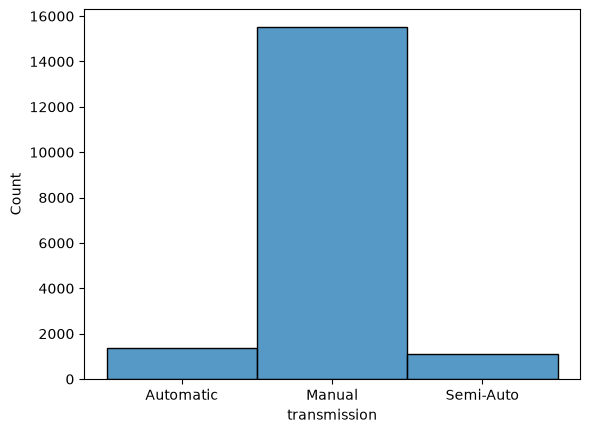

In [59]:
sb.histplot(x=data['transmission'],data=data)

In [60]:
data.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [61]:
# selecting the Dependent columns
x = data.drop('price',axis=1)
x

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,Manual,5007,Petrol,145,57.7,1.2


In [62]:
# performing one hot encoding on categorical columns 
catcols = x.select_dtypes(include='object')


C:\Users\prita\AppData\Local\Temp\ipykernel_11356\62796869.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  catcols = x.select_dtypes(include='object')


In [63]:
catcols.columns

Index(['model', 'transmission', 'fuelType'], dtype='str')

In [64]:
for i in catcols.columns:
    print(x[i].unique())

<ArrowStringArray>
[               'Fiesta',                 'Focus',                  'Puma',
                  'Kuga',              'EcoSport',                 'C-MAX',
                'Mondeo',                   'Ka+',        'Tourneo Custom',
                 'S-MAX',                 'B-MAX',                  'Edge',
       'Tourneo Connect',           'Grand C-MAX',                    'KA',
                'Galaxy',               'Mustang', 'Grand Tourneo Connect',
                'Fusion',                'Ranger',              'Streetka',
                'Escort',       'Transit Tourneo']
Length: 23, dtype: str
<ArrowStringArray>
['Automatic', 'Manual', 'Semi-Auto']
Length: 3, dtype: str
<ArrowStringArray>
['Petrol', 'Diesel', 'Hybrid', 'Electric', 'Other']
Length: 5, dtype: str


In [65]:
x = pd.get_dummies(x,columns=catcols.columns)
x=x.astype(int)
x

,year,mileage,tax,mpg,engineSize,model_B-MAX,model_C-MAX,model_EcoSport,model_Edge,model_Escort,...,model_Tourneo Custom,model_Transit Tourneo,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
1,2018,9083,150,57,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2,2017,12456,150,57,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
3,2019,10460,145,40,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
4,2019,1482,145,48,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,16700,150,47,1,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
17962,2014,40700,30,57,1,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
17963,2015,7010,20,67,1,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
17964,2018,5007,145,57,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1


In [66]:
# Scaling the columns using standard scaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numcols = x.select_dtypes(include='number')
x[numcols.columns] = scaler.fit_transform(x[numcols.columns])


In [67]:
numcols.columns


Index(['year', 'mileage', 'tax', 'mpg', 'engineSize', 'model_B-MAX',
       'model_C-MAX', 'model_EcoSport', 'model_Edge', 'model_Escort',
       'model_Fiesta', 'model_Focus', 'model_Fusion', 'model_Galaxy',
       'model_Grand C-MAX', 'model_Grand Tourneo Connect', 'model_KA',
       'model_Ka+', 'model_Kuga', 'model_Mondeo', 'model_Mustang',
       'model_Puma', 'model_Ranger', 'model_S-MAX', 'model_Streetka',
       'model_Tourneo Connect', 'model_Tourneo Custom',
       'model_Transit Tourneo', 'transmission_Automatic',
       'transmission_Manual', 'transmission_Semi-Auto', 'fuelType_Diesel',
       'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other',
       'fuelType_Petrol'],
      dtype='str')

In [68]:
x.head(10)

,year,mileage,tax,mpg,engineSize,model_B-MAX,model_C-MAX,model_EcoSport,model_Edge,model_Escort,...,model_Tourneo Custom,model_Transit Tourneo,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.065128,-0.380998,0.591358,-0.042122,-0.447984,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.062092,-0.007461,3.492934,-2.517747,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.689320
1,0.552866,-0.733359,0.591358,-0.042122,-0.447984,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.062092,-0.007461,-0.286292,0.397180,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.689320
2,0.065128,-0.560132,0.591358,-0.042122,-0.447984,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.062092,-0.007461,-0.286292,0.397180,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.689320
3,1.040605,-0.662640,0.510727,-1.721198,-0.447984,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.062092,-0.007461,-0.286292,0.397180,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.689320
4,1.040605,-1.123724,0.510727,-0.931045,-0.447984,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.062092,-0.007461,3.492934,-2.517747,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.689320
5,-0.910349,0.619849,0.510727,-1.029814,-0.447984,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.062092,-0.007461,-0.286292,0.397180,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.689320
6,1.040605,-1.095632,0.510727,-0.733506,-0.447984,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.062092,-0.007461,-0.286292,0.397180,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.689320
7,0.065128,-0.529420,0.510727,-0.338430,-0.447984,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.062092,-0.007461,-0.286292,0.397180,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.689320
8,1.040605,-0.845780,0.510727,-1.523660,1.820472,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.062092,-0.007461,3.492934,-2.517747,-0.253771,1.455340,-0.010551,-0.035015,-0.007461,-1.450705
9,0.552866,1.272546,0.510727,0.352954,-0.447984,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.062092,-0.007461,-0.286292,0.397180,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.689320


In [69]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=42)
print(f"Shape of x_train:{X_train.shape}")
print(f"Shape of y_train:{y_train.shape}")
print(f"Shape of x_test:{X_test.shape}")
print(f"Shape of y_test:{y_test.shape}")


Shape of x_train:(14372, 36)
Shape of y_train:(14372,)
Shape of x_test:(3594, 36)
Shape of y_test:(3594,)


In [70]:
"""Q3. (Building Logistic Regression Model) 
Train a Logistic Regression model: 
Import LogisticRegression from sklearn. 
Create the model and fit it on the training data (X_train, y_train). 
"""

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train,y_train)

d:\python programs\Industrial traning\python with github\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [71]:
"""Q4. (Making Predictions) 
Use the trained model to predict on the test data. 
Store predictions in y_pred. 
Print the first 10 actual values (y_test) and predicted values (y_pred). 
"""
y_pred = model.predict(X_test)


In [72]:
# comparing first 10 values of the y test and y pred
for i in range(10):
    print(f"Predicted value:{y_pred[i]}|Actual value:{y_test.iloc[i]}")

Predicted value:7999|Actual value:6995
Predicted value:10000|Actual value:8999
Predicted value:8500|Actual value:7998
Predicted value:5998|Actual value:5491
Predicted value:3995|Actual value:3790
Predicted value:17500|Actual value:18200
Predicted value:24995|Actual value:22998
Predicted value:9498|Actual value:11000
Predicted value:11000|Actual value:7600
Predicted value:20490|Actual value:14985


In [73]:
"""Q5. (Confusion Matrix) 
Create a Confusion Matrix using confusion_matrix(y_test, y_pred). 
Display the matrix. 
Label TN, FP, FN, and TP in the output. 
"""

from sklearn.metrics import confusion_matrix as c 
mat = c(y_test, y_pred)
mat

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1490, 1490))

In [74]:
print(f"TN:{mat[0][0]}")
print(f"Fp:{mat[0][1]}")
print(f"FN:{mat[1][0]}")
print(f"TP:{mat[1][1]}")

TN:0
Fp:0
FN:0
TP:0


In [75]:
"""Q6. (Model Evaluation Metrics) 
Calculate the following metrics: 
Accuracy 
Precision 
Recall 
F1 Score 
"""
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
#precision = precision_score(y_test, y_pred)
#recall = recall_score(y_test, y_pred)
#F1_score = f1_score(y_test, y_pred)

In [76]:
print(f"accuracy:{accuracy}")
# print(f"precision:{precision}")
# print(f"Recall:{recall}")
# print(f"F1_score:{F1_score}")

accuracy:0.02587646076794658


In [77]:
columns = x.columns

In [78]:
from sklearn.metrics import classification_report as r
report = r(y_pred,y_test)
print(report)

d:\python programs\Industrial traning\python with github\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

         495       0.00      0.00      0.00         0
         675       0.00      0.00      0.00         1
         694       0.00      0.00      0.00         0
         999       0.00      0.00      0.00         0
        1295       0.00      0.00      0.00         0
        1299       0.00      0.00      0.00         1
        1449       0.00      0.00      0.00         0
        1475       0.00      0.00      0.00         0
        1500       0.00      0.00      0.00         2
        1595       0.00      0.00      0.00         0
        1695       0.00      0.00      0.00         8
        1795       0.00      0.00      0.00         0
        1799       0.00      0.00      0.00         0
        1850       0.00      0.00      0.00         1
        1995       0.00      0.00      0.00         2
        1999       0.00      0.00      0.00         6
        2175       0.00      0.00      0.00         0
        2195       0.00    

d:\python programs\Industrial traning\python with github\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\python programs\Industrial traning\python with github\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\python programs\Industrial traning\python with github\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn

In [87]:



import joblib as jb
jb.dump(model,"ford_car_dataset.pkl")
jb.dump(scaler,"scaler.pkl")
jb.dump(columns,"columns.pkl")
print("Model is dumped!")

Model is dumped!


In [89]:
"""Q8. (Loading & Testing Saved Model)
Load the saved model and objects.
Create sample input data (one patient record).
Preprocess the input (encoding + scaling).
Make a prediction using the loaded model and print the result."""

mdl = jb.load("ford_car_dataset.pkl")
sclr = jb.load("scaler.pkl")
column = jb.load("columns.pkl")

In [81]:
p = x.head(1).copy()
p

,year,mileage,tax,mpg,engineSize,model_B-MAX,model_C-MAX,model_EcoSport,model_Edge,model_Escort,...,model_Tourneo Custom,model_Transit Tourneo,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.065128,-0.380998,0.591358,-0.042122,-0.447984,-0.141978,-0.176538,-0.260658,-0.108227,-0.007461,...,-0.062092,-0.007461,3.492934,-2.517747,-0.253771,-0.687125,-0.010551,-0.035015,-0.007461,0.68932


In [82]:
# Encoding the categorical columns
catco = p.select_dtypes(include='object')
p = pd.get_dummies(p, columns=catco.columns)


In [83]:
# Scaling the numerical columns 
numco = p.select_dtypes(include='number')
p[numco.columns] = sclr.transform(p[numco.columns])
p

,year,mileage,tax,mpg,engineSize,model_B-MAX,model_C-MAX,model_EcoSport,model_Edge,model_Escort,...,model_Tourneo Custom,model_Transit Tourneo,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,-983.671698,-1.199855,-1.818042,-5.676125,-3.732674,-1.162136,-1.207704,-1.328601,-1.11994,-1.007516,...,-1.065947,-1.007516,12.914296,-9.8568,-1.31817,-2.159265,-1.010663,-1.036241,-1.007516,0.024457


In [84]:
# adding the missing columns
for fn in column:
    if fn not in p.columns:
        p[fn]=0
        print(f"Added column is:{fn}")

In [85]:
# Reorder columns to match training data
p = p.reindex(columns=column, fill_value=0)
predection = mdl.predict(p)



In [86]:
predection

array([1299])